# Проект: Маркетинг

Интернет-магазин собирает историю покупателей, проводит рассылки предложений и
планирует будущие продажи. Для оптимизации процессов надо выделить пользователей,
которые готовы совершить покупку в ближайшее время.

Цель:
Предсказать вероятность покупки в течение 90 дней

## Настройка окружения

### Импорты

In [ ]:
# %pip install -Uq numpy matplotlib contourpy scikit-learn scipy pandas pyarrow
%pip install -Uq pandas pandas-stubs
%pip install -Uq plotly
# %pip install -Uq shap
%pip install -Uq phik
# %pip install -Uq lightgbm
%pip install -Uq catboost
%pip install -Uq optuna

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import optuna # type: ignore
import seaborn as sns
import math

import warnings

from catboost import CatBoostClassifier  # type: ignore
from phik import phik_matrix
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
)

from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier

### Настройки отображения

In [3]:
# output settings
warnings.filterwarnings("ignore")

options = {
    "display.max_rows": None,
    "display.max_columns": None,
    "display.float_format": "{:,.2f}".format,
    "display.max_colwidth": None,
}

# Применяем опции через цикл
for option, value in options.items():
    pd.set_option(option, value)

### Объявление функций

In [4]:
def check_size(current_df: pd.DataFrame, original_df: pd.DataFrame):
    print("Количество записей в текущем датасете: {}".format(len(current_df)))
    print("Количество записей в оригинальном датасете: {}".format(len(original_df)))
    print("Процент от начального объема данных: {:.2%}".format(len(current_df) / len(original_df)))

In [5]:
import os

HOST = "https://code.s3.yandex.net"
HTTP_PREFIX = "http"


# load csv
def load_csv(dataset_path: str, **kwargs):
    # check server request --> relative path --> absolute path --> yandex server request
    path = (
        dataset_path
        if dataset_path.startswith(HTTP_PREFIX)
        else "." + dataset_path if os.path.exists("." + dataset_path)
        else dataset_path if os.path.exists(dataset_path)
        else HOST + dataset_path
    )
    print("Dataset path:", path)
    try:
        return pd.read_csv(filepath_or_buffer=path, **kwargs)
    except Exception as ex:
        print("Could not load csv. Exception:", str(ex))

In [6]:
def describe_dataset(df):
    """
    Выводит общую информацию и статистику по датасету pandas.

    Параметры:
    - df (pandas.DataFrame): Исходный датасет.
    """
    # 1. Общая информация о датасете
    print("*** Общая информация ***\n")
    print(df.info())
    print("\n")

    # 2. Базовая статистика по данным
    print("*** Базовая статистика ***")
    display(df.describe())
    print("\n")

    # 3. Информация по колонкам
    print("*** Информация по колонкам ***")
    column_info = pd.DataFrame(
        {
            "type": df.dtypes,
            "na_count": df.isna().sum(),
            "empty_count": (df == "").sum(),
            "unique_count": df.nunique(),
        }
    )
    display(column_info)
    print("\n")

    # 4. Количество дубликатов
    duplicates = df.duplicated().sum()
    print(f"*** Количество дубликатов: {duplicates} ***")
    print("\n")

    # 5. Первые 5 строк датасета
    print("*** Первые 5 строк датасета ***")
    display(df.head())

## Загрузка данных

Проведем первичную (предварительную) загрузку небольшого количества строк данных для каждого датасета, чтобы посмотреть на данные и оценить их

In [7]:
df_dict = {
    "df_apparel_messages": "apparel-messages.csv",
    "df_apparel_purchases": "apparel-purchases.csv",
    "df_apparel_target_binary": "apparel-target_binary.csv",
    # "df_full_campaign_daily_event_channel": "full_campaign_daily_event_channel.csv",
    # "df_full_campaign_daily_event": "full_campaign_daily_event.csv",
}

for df_name, df_file_name in df_dict.items():
    name = df_name
    print("-" * 10, f"start {name}", "-" * 10, "\n")
    path = ".private/" + df_file_name
    df_name = pd.read_csv(path, nrows=5)
    display(df_name.head())
    display(df_name.dtypes)
    print("-" * 10, f"end {name}", "-" * 10, "\n")

---------- start df_apparel_messages ---------- 



,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


bulk_campaign_id     int64
client_id            int64
message_id          object
event               object
channel             object
date                object
created_at          object
dtype: object

---------- end df_apparel_messages ---------- 

---------- start df_apparel_purchases ---------- 



,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,"1,999.00","['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,"2,499.00","['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,"6,499.00","['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,"4,999.00","['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,"4,999.00","['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


client_id         int64
quantity          int64
price           float64
category_ids     object
date             object
message_id       object
dtype: object

---------- end df_apparel_purchases ---------- 

---------- start df_apparel_target_binary ---------- 



,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


client_id    int64
target       int64
dtype: object

---------- end df_apparel_target_binary ---------- 



Предварительные выводы:
- имена колонок корректные
- поля event и channel являются категориями, изменим им тип на category
- поля date и created_at дате (должны быть типа datetime), изменим им тип при загрузке полных данных

In [8]:
df_apparel_messages_original = load_csv(".private/apparel-messages.csv", dtype={"event": "category", "channel": "category"}, parse_dates=["date", "created_at"])
df_apparel_messages = df_apparel_messages_original.copy()

Dataset path: .private/apparel-messages.csv


In [9]:
df_apparel_purchases_original = load_csv(".private/apparel-purchases.csv", parse_dates=["date"])
df_apparel_purchases = df_apparel_purchases_original.copy()

Dataset path: .private/apparel-purchases.csv


In [10]:
df_apparel_target_binary_original = load_csv(".private/apparel-target_binary.csv")
df_apparel_target_binary = df_apparel_target_binary_original.copy()

Dataset path: .private/apparel-target_binary.csv


### Промежуточные выводы

Данные загружены, выглядят корректно, типы признаков правильные

## Предобработка данных

### Первичный анализ данных

In [11]:
df_dict = {
    "df_apparel_messages": df_apparel_messages,
    "df_apparel_purchases": df_apparel_purchases,
    "df_apparel_target_binary": df_apparel_target_binary,
    # "df_full_campaign_daily_event": df_full_campaign_daily_event,
    # "df_full_campaign_daily_event_channel": df_full_campaign_daily_event_channel,
}

In [12]:
for df_name, df in df_dict.items():
    print(f"{'-' * 10} start: {df_name} {'-' * 10}\n")
    describe_dataset(df)
    print(f"\n{'-' * 10} end: {df_name} {'-' * 10}\n")

---------- start: df_apparel_messages ----------

*** Общая информация ***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype         
---  ------            -----         
 0   bulk_campaign_id  int64         
 1   client_id         int64         
 2   message_id        object        
 3   event             category      
 4   channel           category      
 5   date              datetime64[ns]
 6   created_at        datetime64[ns]
dtypes: category(2), datetime64[ns](2), int64(2), object(1)
memory usage: 510.3+ MB
None


*** Базовая статистика ***


,bulk_campaign_id,client_id,date,created_at
count,"12,739,798.00","12,739,798.00",12739798,12739798
mean,"11,604.59","1,515,915,625,574,831,616.00",2023-06-05 02:46:08.357990400,2023-06-05 13:58:11.168689408
min,548.00,"1,515,915,625,468,060,928.00",2022-05-19 00:00:00,2022-05-19 00:14:20
25%,"8,746.00","1,515,915,625,489,149,440.00",2022-12-19 00:00:00,2022-12-19 12:46:30
50%,"13,516.00","1,515,915,625,503,432,192.00",2023-07-20 00:00:00,2023-07-20 17:21:54
75%,"14,158.00","1,515,915,625,591,286,272.00",2023-11-21 00:00:00,2023-11-21 18:13:05
max,"14,657.00","1,515,915,626,010,288,640.00",2024-02-15 00:00:00,2024-02-15 23:58:40
std,"3,259.21","326,551,798.16",NaN,NaN




*** Информация по колонкам ***


,type,na_count,empty_count,unique_count
bulk_campaign_id,int64,0,0,2709
client_id,int64,0,0,53329
message_id,object,0,0,9061667
event,category,0,0,11
channel,category,0,0,2
date,datetime64[ns],0,0,638
created_at,datetime64[ns],0,0,4103539




*** Количество дубликатов: 48610 ***


*** Первые 5 строк датасета ***


...



*** Информация по колонкам ***


,type,na_count,empty_count,unique_count
client_id,int64,0,0,49849
target,int64,0,0,2




*** Количество дубликатов: 0 ***


*** Первые 5 строк датасета ***


,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0



---------- end: df_apparel_target_binary ----------



Найдем все значения категориальных признаков

In [13]:
print("event:\n", df_apparel_messages["event"].unique().tolist())
print("channel:\n", df_apparel_messages["channel"].unique().tolist())

event:
 ['open', 'click', 'purchase', 'send', 'unsubscribe', 'hbq_spam', 'hard_bounce', 'subscribe', 'soft_bounce', 'complain', 'close']
channel:
 ['email', 'mobile_push']


Предварительные выводы:
- данные не содержат пропусков, но содержат дубликаты
- данные за период Май 2022 - Ферваль 2024
- в датасете df_apparel_purchases меньше уникальных client_id, чем в df_apparel_messages. Вероятно, разница из-за "мертвых" клиентов, которые не совершали покупок в указанный период
- поле message_id состоит из объединения нескольких признаков: client_id, bulk_campaign_id, specific_message_id

### Выделение message_id

In [14]:
# Проверочное условие
expected_pattern = df_apparel_messages['client_id'].astype(str) + '-' + df_apparel_messages['bulk_campaign_id'].astype(str) + '-' + df_apparel_messages['message_id'].str.split('-').str[-1]
matches = expected_pattern == df_apparel_messages['message_id']

print(f"Количество записей, не соответствующих шаблону: {df_apparel_messages[~matches].shape[0]}")

Количество записей, не соответствующих шаблону: 0


In [15]:
df_apparel_messages["message_id"] = df_apparel_messages["message_id"].apply(lambda x: x.split("-")[-1])
df_apparel_messages.head()

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


In [16]:
df_apparel_purchases["message_id"] = df_apparel_purchases["message_id"].apply(lambda x: x.split("-")[-1])
df_apparel_purchases.head()

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,"1,999.00","['4', '28', '57', '431']",2022-05-16,627b661e9736d
1,1515915625468169594,1,"2,499.00","['4', '28', '57', '431']",2022-05-16,627b661e9736d
2,1515915625471138230,1,"6,499.00","['4', '28', '57', '431']",2022-05-16,6282242f27843
3,1515915625471138230,1,"4,999.00","['4', '28', '244', '432']",2022-05-16,6282242f27843
4,1515915625471138230,1,"4,999.00","['4', '28', '49', '413']",2022-05-16,6282242f27843


### Наличие дубликатов

Проверим наличие явных дубликатов

In [17]:
def detect_duplicates(df):
    """
    Выводит общее количество дубликатов, первые 5 строк с дубликатами или сообщение "Явных дубликатов не обнаружено".
    
    Параметры:
    - df (pandas.DataFrame): Исходный датасет.
    """
    # Поиск дубликатов
    duplicated_rows = df[df.duplicated()]

    # Вывод результата
    if len(duplicated_rows) > 0:
        print(f"Общее количество дубликатов: {len(duplicated_rows)}")
        display(duplicated_rows.head())
    else:
        print("Явных дубликатов не обнаружено.")

In [18]:
df_dict = {
    "df_apparel_messages": df_apparel_messages,
    "df_apparel_purchases": df_apparel_purchases,
}

for df_name, df in df_dict.items():
    print(f"{'-' * 10} start: {df_name} {'-' * 10}\n")
    detect_duplicates(df)
    print(f"\n{'-' * 10} end: {df_name} {'-' * 10}\n")

---------- start: df_apparel_messages ----------

Общее количество дубликатов: 48610


,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
964232,5723,1515915625554535987,62e2af08e00da,click,mobile_push,2022-07-28,2022-07-28 15:58:56
966466,5723,1515915625483569932,62e2af0790ad5,click,mobile_push,2022-07-28,2022-07-28 16:07:12
967282,5723,1515915625736038297,62e2af0a17cba,click,mobile_push,2022-07-28,2022-07-28 16:09:56
967567,5723,1515915625753898206,62e2af0a21ecd,click,mobile_push,2022-07-28,2022-07-28 16:12:24
967904,5723,1515915625626349443,62e2af09c0fd3,click,mobile_push,2022-07-28,2022-07-28 16:15:02



---------- end: df_apparel_messages ----------

---------- start: df_apparel_purchases ----------

Общее количество дубликатов: 73020


,client_id,quantity,price,category_ids,date,message_id
12,1515915625491869271,2,599.00,"['4', '27', '350', '1392']",2022-05-16,61a72488d6a0f
22,1515915625566606509,1,299.00,"['5562', '5634', '5579', '710']",2022-05-16,627b66245401d
42,1515915625468070175,1,"2,199.00","['4', '27', '142', '496']",2022-05-17,6283414668daa
59,1515915625468126078,1,"1,499.00","['4', '28', '275', '421']",2022-05-17,6283411f7c0cc
62,1515915625468141317,1,49.00,"['4', '27', '38', '481']",2022-05-17,6283412e01078



---------- end: df_apparel_purchases ----------



### Выборочная проверка дубликатов

In [19]:
df_apparel_messages.query("client_id == 1515915625554535987 and message_id == '62e2af08e00da'").head()

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
964169,5723,1515915625554535987,62e2af08e00da,send,mobile_push,2022-07-28,2022-07-28 15:58:49
964231,5723,1515915625554535987,62e2af08e00da,click,mobile_push,2022-07-28,2022-07-28 15:58:56
964232,5723,1515915625554535987,62e2af08e00da,click,mobile_push,2022-07-28,2022-07-28 15:58:56
968252,5723,1515915625554535987,62e2af08e00da,purchase,mobile_push,2022-07-28,2022-07-28 17:29:17
968266,5723,1515915625554535987,62e2af08e00da,purchase,mobile_push,2022-07-28,2022-07-28 17:38:31


In [20]:
df_apparel_purchases.query("client_id == 1515915625554535987 and message_id == '62e2af08e00da'").head()

,client_id,quantity,price,category_ids,date,message_id
26803,1515915625554535987,1,199.00,"['4', '28', '213', '417']",2022-07-28,62e2af08e00da
26804,1515915625554535987,1,399.00,"['4', '28', '239', '418']",2022-07-28,62e2af08e00da
26805,1515915625554535987,1,399.00,"['4', '28', '239', '418']",2022-07-28,62e2af08e00da
26806,1515915625554535987,1,199.00,"['4', '28', '275', '673']",2022-07-28,62e2af08e00da
26807,1515915625554535987,1,999.00,"['4', '28', '57', '431']",2022-07-28,62e2af08e00da


Вряд ли возможно по пуш уведомлению кликнуть дважды и в одно время с точностью до секунды. Пуш ведет либо на сайт, либо в мобильное приложение. Кажется, можно сделать несколько одинаковых заказов в один день в приложении или на сайте, если их не закрывать после перехода. Другое дело, что с точки зрения логики поведения это выглядит очень нелогично.

Посмотрим дубликаты для email рассылок.

In [21]:
mask = df_apparel_messages.duplicated()
df_apparel_messages[mask].query("channel == 'email'").head()

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
1404039,6251,1515915625489095763,6311b13a4cf78,click,email,2022-09-03,2022-09-03 12:58:02
1855332,6963,1515915625491167405,633fcb4b0f3aa,send,email,2022-10-07,2022-10-07 08:43:51
2206285,7475,1515915625489705746,635f80baf2917,click,email,2022-10-31,2022-10-31 11:11:49
2207643,7475,1515915625474233185,635f80ad6e24a,click,email,2022-10-31,2022-10-31 14:29:00
2222046,7475,1515915625470759244,635f80b16e23a,click,email,2022-11-01,2022-11-01 02:38:13


In [22]:
df_apparel_messages.query("client_id == 1515915625489705746 and message_id == '635f80baf2917'").head()

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
2200737,7475,1515915625489705746,635f80baf2917,send,email,2022-10-31,2022-10-31 09:34:31
2206281,7475,1515915625489705746,635f80baf2917,open,email,2022-10-31,2022-10-31 11:11:29
2206284,7475,1515915625489705746,635f80baf2917,click,email,2022-10-31,2022-10-31 11:11:49
2206285,7475,1515915625489705746,635f80baf2917,click,email,2022-10-31,2022-10-31 11:11:49
2231774,7475,1515915625489705746,635f80baf2917,purchase,email,2022-11-01,2022-11-01 15:00:50


In [23]:
df_apparel_purchases.query("client_id == 1515915625489705746 and message_id == '635f80baf2917'").head()

,client_id,quantity,price,category_ids,date,message_id
41514,1515915625489705746,1,"2,450.00","['4', '28', '104', '429']",2022-11-01,635f80baf2917


А вот кликнуть дважды по кнопке в email в одну секунду выглядит вполне возможным.

Тем не менее, дублирование негативно сказывается на результатах обучения и предсказательных характеристиках моделей машинного обучения. Устранение дубликатов способствует повышению надёжности и стабильности моделей.

In [24]:
df_apparel_messages = df_apparel_messages.drop_duplicates()
check_size(df_apparel_messages, df_apparel_messages_original)

Количество записей в текущем датасете: 12691188
Количество записей в оригинальном датасете: 12739798
Процент от начального объема данных: 99.62%


In [25]:
df_apparel_purchases = df_apparel_purchases.drop_duplicates()
check_size(df_apparel_purchases, df_apparel_purchases_original)

Количество записей в текущем датасете: 129188
Количество записей в оригинальном датасете: 202208
Процент от начального объема данных: 63.89%


### Промежуточные выводы

В ходе предварительной обработки данных было сделано следующее:
- проведена проверка на наличие пропусков в данных. Пропусков не обнаружено
- проведена проверка на наличие дубликатов, явные дубликаты удалены
- проведена проверка на полноту данных после проведения предобработки

## Исследовательский анализ данных

### Количественные признаки

In [26]:
def visualize_numerical_distribution_and_range(df, bins_rule="sturges", numerical_cols=None):
    """
    Рисует графики распределения (гистограмма) и размаха (коробчатая диаграмма) для всех числовых признаков.

    Параметры:
    - df (pandas.DataFrame): Исходный датасет.
    - bins_rule (str): Правило для автоматического подбора количества корзин. Возможные значения:
                     'sturges' (правило Стерджеса) или 'sqrt' (корень квадратный).
    """
    # Отбираем только числовые столбцы
    if numerical_cols is None or not list(numerical_cols):
        numerical_cols = df.select_dtypes(include=["number"]).columns

    # Функция для автоматического подбора количества корзин
    def auto_binning(data_length, rule=bins_rule):
        if rule == "sturges":
            return int(math.ceil(math.log2(data_length))) + 1
        elif rule == "sqrt":
            return int(math.sqrt(data_length))
        else:
            raise ValueError("Invalid binning rule provided.")

    # Проходим по каждому числовому столбцу и строим графики
    for col in numerical_cols:
        # Подбор оптимального количества корзин
        optimal_bins = auto_binning(len(df))

        # Гистограмма с боксплотом (график распределения и размаха)
        fig = px.histogram(
            df,
            x=col,
            marginal="box",
            barmode="group",
            nbins=optimal_bins,
            title=f'Распределение и размах для признака "{col}"',
        )

        # Визуализация графика
        fig.show()

In [27]:
numeric_columns = df_apparel_messages.select_dtypes(include=['number']).columns.drop(['client_id'])
numeric_columns

Index(['bulk_campaign_id'], dtype='object')

In [28]:
# visualize_numerical_distribution_and_range(df_apparel_messages, "sqrt", numeric_columns)

# Провести анализ количественных признаков для датасета df_apparel_messages не получилось, 
# т.к. падает ядро и docker container с jupyter server уходит в reboot.
# Такое поведение, вероятно, связано с большим объемом данных в датасете

In [29]:
numeric_columns = df_apparel_purchases.select_dtypes(include=['number']).columns.drop(['client_id'])
numeric_columns

Index(['quantity', 'price'], dtype='object')

In [30]:
visualize_numerical_distribution_and_range(df_apparel_purchases, "sqrt", numeric_columns)

Подавляющее большинство покупок было совершено на сумму в пределах 3777 и в количестве 1 шт

### Категориальные признаки

In [31]:
def visualize_categorical_columns(df, categorical_cols=None):
    """
    Строит столбчатые и круговые диаграммы для категориальных признаков датасета.
    
    Параметры:
    - df (pandas.DataFrame): Исходный датасет.
    """
    # Получаем список категориальных столбцов
    if categorical_cols is None or not list(categorical_cols):
        categorical_cols = df.select_dtypes(exclude=['number']).columns
    
    # Для каждого категориального столбца строим диаграммы
    for col in categorical_cols:
        # Частотная таблица для столбца
        freq_table = df[col].value_counts()
        
        # Бар-чарт (столбчатая диаграмма)
        fig_bar = px.bar(freq_table, x=freq_table.index, y=freq_table.values, 
                         labels={"x": f"{col}", "y": "Частота"},
                         title=f"Бар-диаграмма для {col}")
        fig_bar.show()
        
        # Круговая диаграмма (pie chart)
        fig_pie = px.pie(names=freq_table.index, values=freq_table.values, 
                         title=f"Круговая диаграмма для {col}")
        fig_pie.show()

In [32]:
categorical_columns = df_apparel_messages.select_dtypes(include=['category']).columns
categorical_columns

Index(['event', 'channel'], dtype='object')

In [33]:
visualize_categorical_columns(df_apparel_messages, categorical_columns)

Было разослано более 9М сообщений, из которых открыто примерно 3М, а покупку совершили всего в 62.5К случаев.

Большинство уведомлений было push уведомлениями.

### Промежуточные выводы

Был проведен исследовательский анализ количественных и категориальных признаков из датасетов.
- Подавляющее большинство покупок было совершено на сумму в пределах 3777 и в количестве 1 шт
- Разослано более 9М сообщений, из которых открыто примерно 3М, а покупку совершили всего в 62.5К случаев
- Большинство уведомлений было push уведомлениями

## Создание новых признаков

Найдем количество всех event для каждого клиента

In [34]:
df_apparel_messages_pivot = df_apparel_messages.pivot_table(
    values="message_id",
    index="client_id", 
    columns="event", 
    aggfunc="count"
)
df_apparel_messages_pivot.head()

event,click,hard_bounce,hbq_spam,open,purchase,send,soft_bounce,subscribe,unsubscribe,complain,close
client_id,,,,,,,,,,,
1515915625468060902,10,0,0,35,5,126,0,0,1,0,0
1515915625468061003,5,0,0,5,1,154,0,0,0,0,0
1515915625468061099,8,2,0,51,0,215,0,0,0,0,0
1515915625468061100,1,1,0,157,1,267,1,0,0,0,0
1515915625468061170,16,0,0,31,3,243,0,0,0,0,0


Получили общую статистику по реакциям пользователя на рассылки

Найдем максимальную дату покупки из датасета

In [35]:
last_date = df_apparel_purchases['date'].max()
last_date

Timestamp('2024-02-16 00:00:00')

Предоставленые данные до середины февраля 2024, а цель -- предсказать вероятность покупки в ближайшие 90 дней (3 месяца).

Получим статистику по покупкам пользователей

In [36]:
df_apparel_purchases_pivot = df_apparel_purchases.pivot_table(
    values=["price", "quantity"],
    index="client_id", 
    aggfunc="sum",
    fill_value=0
)
df_apparel_purchases_pivot.head()

,price,quantity
client_id,,
1515915625468060902,"4,795.00",5
1515915625468061003,"14,135.00",6
1515915625468061099,299.00,1
1515915625468061100,"1,049.00",1
1515915625468061170,"14,102.00",8


Найдем даты первой и последней покупки

In [37]:
df_apparel_purchases_dates = df_apparel_purchases.groupby("client_id").agg(
    first_buy_date=("date", "min"),
    last_buy_date=("date", "max"),
)
df_apparel_purchases_dates.head()

,first_buy_date,last_buy_date
client_id,,
1515915625468060902,2022-05-27,2022-05-27
1515915625468061003,2023-01-04,2023-01-04
1515915625468061099,2022-05-17,2022-05-17
1515915625468061100,2024-02-10,2024-02-10
1515915625468061170,2023-03-26,2023-06-17


Объединим полученные датасеты

In [38]:
df_clients = df_apparel_messages_pivot.join(df_apparel_purchases_pivot).join(df_apparel_purchases_dates)

df_clients = df_clients.fillna(0)
df_clients['first_buy_date'] = pd.to_datetime(df_clients['first_buy_date'])
df_clients['last_buy_date'] = pd.to_datetime(df_clients['last_buy_date'])

df_clients.head()

,click,hard_bounce,hbq_spam,open,purchase,send,soft_bounce,subscribe,unsubscribe,complain,close,price,quantity,first_buy_date,last_buy_date
client_id,,,,,,,,,,,,,,,
1515915625468060902,10,0,0,35,5,126,0,0,1,0,0,"4,795.00",5.00,2022-05-27,2022-05-27
1515915625468061003,5,0,0,5,1,154,0,0,0,0,0,"14,135.00",6.00,2023-01-04,2023-01-04
1515915625468061099,8,2,0,51,0,215,0,0,0,0,0,299.00,1.00,2022-05-17,2022-05-17
1515915625468061100,1,1,0,157,1,267,1,0,0,0,0,"1,049.00",1.00,2024-02-10,2024-02-10
1515915625468061170,16,0,0,31,3,243,0,0,0,0,0,"14,102.00",8.00,2023-03-26,2023-06-17


Найдем общее количество дней на маркетплейсе и количество дней с последней покупки

In [39]:
df_clients['recent_activity_days'] = (last_date - df_clients['last_buy_date']).dt.days

# когда даты первой и последней покупки совпадают следует добавить 1, иначе будет 0
df_clients['total_days'] = (df_clients['last_buy_date'] - df_clients['first_buy_date']).dt.days + 1 
df_clients.head()

,click,hard_bounce,hbq_spam,open,purchase,send,soft_bounce,subscribe,unsubscribe,complain,close,price,quantity,first_buy_date,last_buy_date,recent_activity_days,total_days
client_id,,,,,,,,,,,,,,,,,
1515915625468060902,10,0,0,35,5,126,0,0,1,0,0,"4,795.00",5.00,2022-05-27,2022-05-27,630,1
1515915625468061003,5,0,0,5,1,154,0,0,0,0,0,"14,135.00",6.00,2023-01-04,2023-01-04,408,1
1515915625468061099,8,2,0,51,0,215,0,0,0,0,0,299.00,1.00,2022-05-17,2022-05-17,640,1
1515915625468061100,1,1,0,157,1,267,1,0,0,0,0,"1,049.00",1.00,2024-02-10,2024-02-10,6,1
1515915625468061170,16,0,0,31,3,243,0,0,0,0,0,"14,102.00",8.00,2023-03-26,2023-06-17,244,84


In [40]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53329 entries, 1515915625468060902 to 1515915626010288690
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   click                 53329 non-null  int64         
 1   hard_bounce           53329 non-null  int64         
 2   hbq_spam              53329 non-null  int64         
 3   open                  53329 non-null  int64         
 4   purchase              53329 non-null  int64         
 5   send                  53329 non-null  int64         
 6   soft_bounce           53329 non-null  int64         
 7   subscribe             53329 non-null  int64         
 8   unsubscribe           53329 non-null  int64         
 9   complain              53329 non-null  int64         
 10  close                 53329 non-null  int64         
 11  price                 53329 non-null  float64       
 12  quantity              53329 non-null  float64  

Добавим к полученному датасету целевой признак

In [41]:
df_apparel_target_binary = df_apparel_target_binary.set_index('client_id')
df_apparel_target_binary.head()

,target
client_id,
1515915625468060902,0
1515915625468061003,1
1515915625468061099,0
1515915625468061100,0
1515915625468061170,0


In [42]:
df_apparel_target_binary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49849 entries, 1515915625468060902 to 1515915626010443624
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   target  49849 non-null  int64
dtypes: int64(1)
memory usage: 778.9 KB


Выберем тип соединения inner, т.к. в противном случае у нас либо не будет статистики, либо целевого признака. Такие данные невозможно использовать для обучения моделей.

In [43]:
df_clients_full = df_clients.join(df_apparel_target_binary, how="inner")
df_clients_full.head()

,click,hard_bounce,hbq_spam,open,purchase,send,soft_bounce,subscribe,unsubscribe,complain,close,price,quantity,first_buy_date,last_buy_date,recent_activity_days,total_days,target
client_id,,,,,,,,,,,,,,,,,,
1515915625468060902,10,0,0,35,5,126,0,0,1,0,0,"4,795.00",5.00,2022-05-27,2022-05-27,630,1,0
1515915625468061003,5,0,0,5,1,154,0,0,0,0,0,"14,135.00",6.00,2023-01-04,2023-01-04,408,1,1
1515915625468061099,8,2,0,51,0,215,0,0,0,0,0,299.00,1.00,2022-05-17,2022-05-17,640,1,0
1515915625468061100,1,1,0,157,1,267,1,0,0,0,0,"1,049.00",1.00,2024-02-10,2024-02-10,6,1,0
1515915625468061170,16,0,0,31,3,243,0,0,0,0,0,"14,102.00",8.00,2023-03-26,2023-06-17,244,84,0


In [44]:
df_clients_full.shape

(41982, 18)

В финальном датасете с новыми признаками осталось почти 42К записей

### Промежуточные выводы

В данном разделе были созданы и добавлены новые признаки. Также проведено объединение всех признаков в один датасет и к нему добавлен целевой признак.

## Корреляционный анализ

In [45]:
def correlation_heatmap(df, interval_cols=None):
    """
    Строит матрицу корреляции с использованием phik_matrix и выводит тепловую карту с аннотациями.
    
    Параметры:
    - df (pandas.DataFrame): Исходный датасет.
    """
    # Отбираем только числовые столбцы
    if interval_cols is None or not list(interval_cols):
        interval_cols = df.select_dtypes(include=["number"]).columns

    # Вычисляем матрицу корреляции Phik
    corr_matrix = phik_matrix(df, interval_cols=interval_cols, verbose=False)

    # Определяем оптимальный размер фигуры
    num_cols = len(corr_matrix.columns)
    size_per_col = 0.7  # размер графика на колонку
    figure_width = num_cols * size_per_col
    figure_height = num_cols * size_per_col

    # Вывод тепловой карты
    plt.figure(figsize=(figure_width, figure_height))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title("Матрица корреляции Phik")
    plt.show()

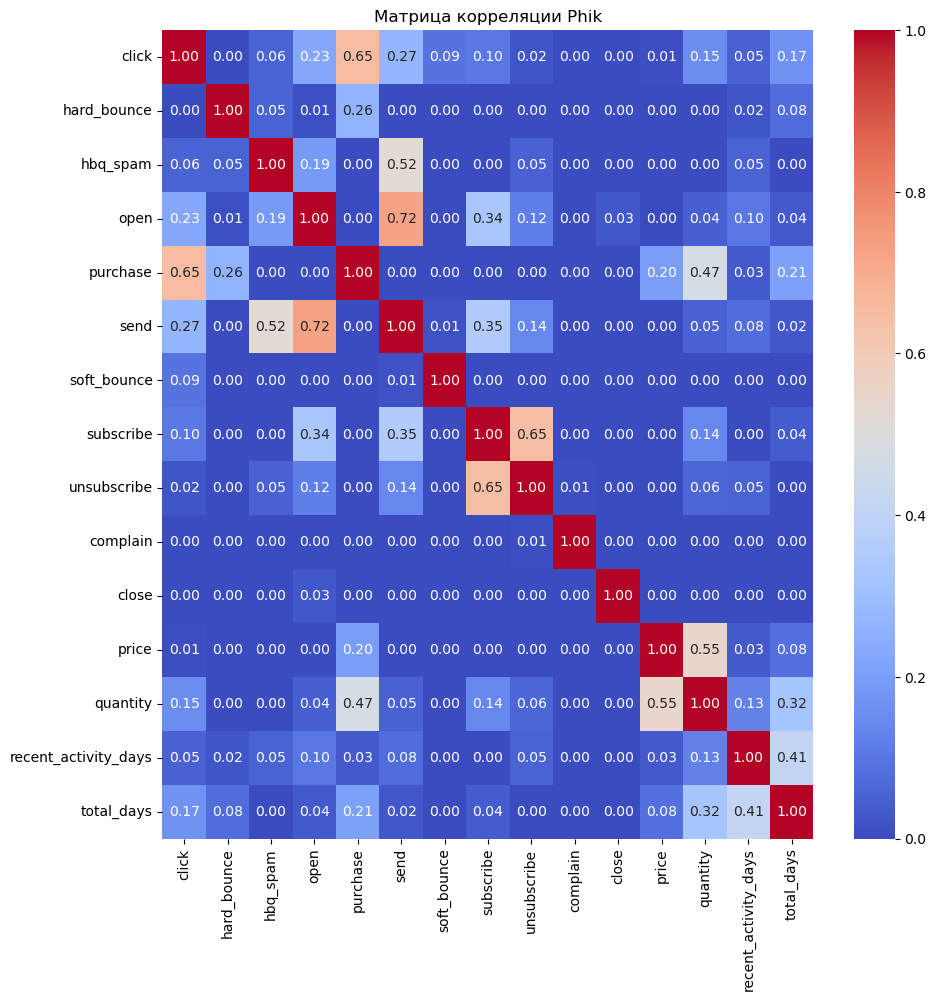

In [46]:
numeric_columns = df_clients_full.select_dtypes(include=["number"]).columns.drop(["target"])

correlation_heatmap(df_clients_full[numeric_columns])

Определим степень зависимости признака покупки от остальных признаков

In [47]:
def correlation_analysis(corr_matrix, target_column):
    """
    Анализирует матрицу корреляции и выводит степень зависимости целевого признака от остальных признаков.
    
    Параметры:
    - corr_matrix (pandas.DataFrame): Матрица корреляции.
    - target_column (str): Название целевого признака.
    """
    # Получаем строку с корреляциями целевого признака
    correlations = round(corr_matrix[target_column].abs(), 2)
    
    # Исключаем сам целевой признак
    correlations = correlations.drop(target_column)
    
    # Классифицируем зависимости согласно таблице
    very_low_dependency = correlations[(correlations >= 0) & (correlations < 0.2)].index.tolist()
    low_dependency = correlations[(correlations >= 0.2) & (correlations < 0.5)].index.tolist()
    medium_dependency = correlations[(correlations >= 0.5) & (correlations < 0.7)].index.tolist()
    high_dependency = correlations[(correlations >= 0.7) & (correlations < 0.9)].index.tolist()
    very_high_dependency = correlations[(correlations >= 0.9) & (correlations <= 1)].index.tolist()
    
    # Вывод результатов
    print(f"Признак {target_column} имеет:")
    if very_high_dependency:
        print(f"- очень высокую зависимость (> 0.9) от признаков {very_high_dependency}")
    if high_dependency:
        print(f"- высокую зависимость (0.7-0.9) от признаков {high_dependency}")
    if medium_dependency:
        print(f"- среднюю зависимость (0.5-0.7) от признаков {medium_dependency}")
    if low_dependency:
        print(f"- слабую зависимость (0.2-0.5) от признаков {low_dependency}")
    if very_low_dependency:
        print(f"- очень слабую зависимость (0-0.2) от признаков {very_low_dependency}")
    if not (very_high_dependency or high_dependency or medium_dependency or low_dependency or very_low_dependency):
        print("- признаков с достаточной степенью зависимости не найдено.")

In [48]:
corr_matrix = phik_matrix(df_clients_full[numeric_columns], verbose=False)

correlation_analysis(corr_matrix, "purchase")

Признак purchase имеет:
- среднюю зависимость (0.5-0.7) от признаков ['click']
- слабую зависимость (0.2-0.5) от признаков ['hard_bounce', 'price', 'quantity', 'total_days']
- очень слабую зависимость (0-0.2) от признаков ['hbq_spam', 'open', 'send', 'soft_bounce', 'subscribe', 'unsubscribe', 'complain', 'close', 'recent_activity_days']


Удалим признаки со очень слабой корреляцией

In [49]:
cols_to_drop = ['hbq_spam', 'open', 'send', 'soft_bounce', 'subscribe', 'unsubscribe', 'complain', 'close', 'recent_activity_days']

df_clients_corr_features = df_clients_full.drop(columns=cols_to_drop)
df_clients_corr_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41982 entries, 1515915625468060902 to 1515915626010261344
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   click           41982 non-null  int64         
 1   hard_bounce     41982 non-null  int64         
 2   purchase        41982 non-null  int64         
 3   price           41982 non-null  float64       
 4   quantity        41982 non-null  float64       
 5   first_buy_date  41982 non-null  datetime64[ns]
 6   last_buy_date   41982 non-null  datetime64[ns]
 7   total_days      41982 non-null  int64         
 8   target          41982 non-null  int64         
dtypes: datetime64[ns](2), float64(2), int64(5)
memory usage: 3.2 MB


### Промежуточные выводы

Матрица корреляции показала следующие зависимости признака purchase (факт совершения покупки в прошлом):
- среднюю зависимость (0.5-0.7) от признаков ['click']
- слабую зависимость (0.2-0.5) от признаков ['hard_bounce', 'price', 'quantity', 'total_days']
- очень слабую зависимость (0-0.2) от признаков ['hbq_spam', 'open', 'send', 'soft_bounce', 'subscribe', 'unsubscribe', 'complain', 'close', 'recent_activity_days']

Признаки с очень слабой корреляцией были удалены из датасета

## Подготовка данных

In [50]:
RANDON_STATE = 1
TEST_SIZE = 0.25

# Отделяем признаки и цель
X = df_clients_corr_features.drop("target", axis=1)
y = df_clients_corr_features["target"]

# Разбиение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDON_STATE
)

# Определение категориальных и числовых признаков
numeric_features = X.select_dtypes(include=["number"]).columns
category_features = X.select_dtypes(exclude=["number"]).columns

# Трансформация данных с помощью пайплайна
preprocessor = ColumnTransformer(
    [
        # ('imputer_before', SimpleImputer(strategy='median')),
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse=False),
            category_features,
        ),
        # ('imputer_after', SimpleImputer(strategy='median')),
    ]
)

Данные подготовлены для обучения моделей

## Обучение моделей

Рассмотри несколько различных моделей классификации. Для поиска лучших гиперпараметров будем использовать optuna

### DecisionTreeClassifier

In [51]:
# Составляем пайплайн
pipeline = Pipeline(
    [("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(random_state=RANDON_STATE))]
)


# Функция для оптимизации с помощью Optuna
def objective(trial):
    # Пробуем разные гиперпараметры
    max_depth = trial.suggest_int("max_depth", 2, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    # Настраиваем гиперпараметры в пайплайне
    pipeline.set_params(
        classifier__max_depth=max_depth,
        classifier__min_samples_split=min_samples_split,
        classifier__min_samples_leaf=min_samples_leaf,
    )

    # Оценка качества модели с помощью кросс-валидации
    scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring="roc_auc")
    return scores["test_score"].mean()


# Настройка Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Лучшие параметры
best_params = study.best_params
best_score = study.best_value
print("\nЛучшие гиперпараметры:", best_params)
print("ROC-AUC на кросс-валидации:", best_score)

[I 2025-12-03 20:15:51,348] A new study created in memory with name: no-name-4b6b5810-9660-4465-8e54-115f8b856da3
[I 2025-12-03 20:15:55,805] Trial 0 finished with value: 0.5921516565934826 and parameters: {'max_depth': 2, 'min_samples_split': 7, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.5921516565934826.
[I 2025-12-03 20:16:00,119] Trial 1 finished with value: 0.5916629390937558 and parameters: {'max_depth': 2, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.5921516565934826.
[I 2025-12-03 20:16:07,233] Trial 2 finished with value: 0.649672989659161 and parameters: {'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.649672989659161.
[I 2025-12-03 20:16:12,631] Trial 3 finished with value: 0.6264160938554362 and parameters: {'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.649672989659161.
[I 2025-12-03 20:16:25,727] Trial 4 finished with value: 0.6275868658


Лучшие гиперпараметры: {'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 6}
ROC-AUC на кросс-валидации: 0.6508812808965432


### Perceptron

In [52]:
# Составляем пайплайн
pipeline = Pipeline(
    [("preprocessor", preprocessor), ("classifier", Perceptron(tol=1e-3, random_state=RANDON_STATE))]
)


# Функция для оптимизации с помощью Optuna
def objective(trial):
    # Пробуем разные гиперпараметры
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    alpha = trial.suggest_float("alpha", 0.0001, 1.0)
    eta0 = trial.suggest_float("eta0", 0.001, 1.0)

    # Настраиваем гиперпараметры в пайплайне
    pipeline.set_params(
        classifier__penalty=penalty, classifier__alpha=alpha, classifier__eta0=eta0
    )

    # Оценка качества модели с помощью кросс-валидации
    scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring="roc_auc")
    return scores["test_score"].mean()


# Настройка Optuna
study = optuna.create_study(direction="maximize")  # Максимизируем ROC-AUC
study.optimize(objective, n_trials=50)  # Количество испытаний

# Лучшие параметры
best_params = study.best_params
best_score = study.best_value
print("\nЛучшие гиперпараметры:", best_params)
print("ROC-AUC на кросс-валидации:", best_score)

[I 2025-12-03 20:22:58,433] A new study created in memory with name: no-name-00c57b2e-c96f-4150-9780-6de0f5c7cb78
[I 2025-12-03 20:23:01,157] Trial 0 finished with value: 0.48526166560484346 and parameters: {'penalty': 'l2', 'alpha': 0.016805578463995528, 'eta0': 0.4032251512210202}. Best is trial 0 with value: 0.48526166560484346.
[I 2025-12-03 20:23:05,621] Trial 1 finished with value: 0.5 and parameters: {'penalty': 'elasticnet', 'alpha': 0.3588712499852015, 'eta0': 0.9165441379444484}. Best is trial 1 with value: 0.5.
[I 2025-12-03 20:23:10,074] Trial 2 finished with value: 0.5 and parameters: {'penalty': 'l1', 'alpha': 0.5438390325277129, 'eta0': 0.7581704923696215}. Best is trial 1 with value: 0.5.
[I 2025-12-03 20:23:14,562] Trial 3 finished with value: 0.5 and parameters: {'penalty': 'elasticnet', 'alpha': 0.9467260743459368, 'eta0': 0.26433262693769977}. Best is trial 1 with value: 0.5.
[I 2025-12-03 20:23:16,962] Trial 4 finished with value: 0.41312267647628 and parameters: {


Лучшие гиперпараметры: {'penalty': 'l2', 'alpha': 0.5097238745118539, 'eta0': 0.26678697988153216}
ROC-AUC на кросс-валидации: 0.5671833326186446


### CatBoost

In [53]:
# Составляем пайплайн
pipeline = Pipeline(
    [
        ("classifier", CatBoostClassifier(task_type="CPU", verbose=0, random_state=RANDON_STATE)),
    ]
)


# Функция для оптимизации с помощью Optuna
def objective(trial):
    # Пробуем разные гиперпараметры
    iterations = trial.suggest_int("iterations", 100, 500)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
    depth = trial.suggest_int("depth", 4, 10)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1, 10)
    random_strength = trial.suggest_float('random_strength', 0.1, 1.0)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0)

    # Настраиваем гиперпараметры в пайплайне
    pipeline.set_params(
        classifier__iterations=iterations,
        classifier__learning_rate=learning_rate,
        classifier__depth=depth,
        classifier__l2_leaf_reg=l2_leaf_reg,
        classifier__random_strength=random_strength,
        classifier__bagging_temperature=bagging_temperature,
    )

    # Оценка качества модели с помощью кросс-валидации
    scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring="roc_auc")
    return scores["test_score"].mean()


# Настройка Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Лучшие параметры
best_params = study.best_params
best_score = study.best_value
print("\nЛучшие гиперпараметры:", best_params)
print("ROC-AUC на кросс-валидации:", best_score)

[I 2025-12-03 20:25:49,414] A new study created in memory with name: no-name-2cefe752-db4e-4829-b163-8b1f7c1338c9
[I 2025-12-03 20:26:03,634] Trial 0 finished with value: 0.6240197406056917 and parameters: {'iterations': 439, 'learning_rate': 0.2322339600151949, 'depth': 8, 'l2_leaf_reg': 8.439535285112415, 'random_strength': 0.6310326992428785, 'bagging_temperature': 0.7100827583155771}. Best is trial 0 with value: 0.6240197406056917.
[I 2025-12-03 20:26:09,374] Trial 1 finished with value: 0.6719283729145225 and parameters: {'iterations': 321, 'learning_rate': 0.2572032741108098, 'depth': 4, 'l2_leaf_reg': 5.430164379206557, 'random_strength': 0.653296399835872, 'bagging_temperature': 0.9078070793389436}. Best is trial 1 with value: 0.6719283729145225.
[I 2025-12-03 20:26:21,313] Trial 2 finished with value: 0.7044672187990466 and parameters: {'iterations': 457, 'learning_rate': 0.03782753387011235, 'depth': 7, 'l2_leaf_reg': 4.738953111778274, 'random_strength': 0.533226234214101, '


Лучшие гиперпараметры: {'iterations': 125, 'learning_rate': 0.1261465533366809, 'depth': 4, 'l2_leaf_reg': 1.215379783072049, 'random_strength': 0.9811095024271498, 'bagging_temperature': 0.28208929608955163}
ROC-AUC на кросс-валидации: 0.7237008549404939


### Промежуточные выводы

На кросс-валидации модели показали следующие метрики ROC-AUC:
- DecisionTreeClassifier: 0.65
- Perceptron: 0.57
- CatBoostClassifier: 0.72

Лучшей признана модель CatBoostClassifier. Лучшие гиперпараметры: {'iterations': 161, 'learning_rate': 0.21569432286417053, 'depth': 4, 'l2_leaf_reg': 5.090968712687669, 'random_strength': 0.6469160400561126, 'bagging_temperature': 0.16515566522068773}

## Предсказание на тестовой выборке

In [54]:
# Обучение финальной модели с лучшими параметрами
clf_final = CatBoostClassifier(verbose=0, **best_params)
clf_final.fit(X_train, y_train)

# Прогноз вероятности
probs_final = clf_final.predict_proba(X_test)[:, 1]
auc_final = roc_auc_score(y_test, probs_final)

print("\nFinal ROC-AUC:", auc_final)


Final ROC-AUC: 0.7782691956741741


На тестовой выборке модель показала значение метрики ROC-AUC = 0.78, что лучше поставленных требований (0.75)

## Общий вывод

В данной работе был проведен анализ данных о рекламных рассылках и покупках в Интернет-магазине для планирования будущих продаж.

Цель:
Предсказать вероятность покупки в течение 90 дней

В ходе предварительной обработки данных было сделано следующее:
- проведена проверка на наличие пропусков в данных. Пропусков не обнаружено
- проведена проверка на наличие дубликатов, явные дубликаты удалены
- проведена проверка на полноту данных после проведения предобработки

Был проведен исследовательский анализ количественных и категориальных признаков из датасетов.
- Подавляющее большинство покупок было совершено на сумму в пределах 3777 и в количестве 1 шт
- Разослано более 9М сообщений, из которых открыто примерно 3М, а покупку совершили всего в 62.5К случаев. Конверсия цепочки событий send -> open -> purchase составляет 100% -> 30% -> 0.7%
- Большинство уведомлений было push уведомлениями

Были созданы и добавлены новые признаки. Также проведено объединение всех признаков в один датасет.

Матрица корреляции показала следующие зависимости признака purchase (факт совершения покупки в прошлом):
- среднюю зависимость (0.5-0.7) от признаков ['click']
- слабую зависимость (0.2-0.5) от признаков ['hard_bounce', 'price', 'quantity', 'total_days']
- очень слабую зависимость (0-0.2) от признаков ['hbq_spam', 'open', 'send', 'soft_bounce', 'subscribe', 'unsubscribe', 'complain', 'close', 'recent_activity_days']

Признаки с очень слабой корреляцией были удалены из датасета

На кросс-валидации модели показали следующие метрики ROC-AUC:
- DecisionTreeClassifier: 0.65
- Perceptron: 0.57
- CatBoostClassifier: 0.72

Лучшей признана модель CatBoostClassifier. Лучшие гиперпараметры: {'iterations': 161, 'learning_rate': 0.21569432286417053, 'depth': 4, 'l2_leaf_reg': 5.090968712687669, 'random_strength': 0.6469160400561126, 'bagging_temperature': 0.16515566522068773}

На тестовой выборке лучшая модель показала значение метрики ROC-AUC = 0.78, что лучше поставленных требований (0.75)